# 1. Dataset Introduction

This project focuses on a dataset of NBA players. The data set includes all 573 players for the 2024-2025 year. The data used can be found at
https://www.basketball-reference.com/leagues/NBA_2025_standings.html. I also took the top 100 players made by ESPN from this link https://www.espn.com/nba/story/_/id/41555759/nba-rank-2024-2025-best-players-100-51. I've combined the two data sets and set a new variable of tier to all that are in the top 100 labeled in the "Top 100" and the others as "Others". The main variables of interest that we have are the Player Efficiency Rating (PER), Box Plus Minus (BPM), and the Tier variable that I've created. The dataset itself just has the stats of the given players, but through research questions I hope to develop a better understanding of how the PER relates to the different aspects of players and how it can relate to both the top 100 players and the BPM.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the datasets
top_df = pd.read_excel("toptier.xlsx")
bottom_df = pd.read_csv("bottom tier.csv")

# Add a 'Tier' column
top_df['Tier'] = 'Top 100'
bottom_df['Tier'] = 'Others'

# Combine datasets
nba_df = pd.concat([top_df, bottom_df], ignore_index=True)
nba_df

,Rk,Player,Unnamed: 2,Team,PER,BPM,Tier
0,177,Anfernee Simons,NaN,POR,15.9,0.2,Top 100
1,181,Chris Paul,NaN,GSW,14.7,1.0,Top 100
2,70,Mike Conley,NaN,MIN,15.8,3.4,Top 100
3,54,Herbert Jones,NaN,NOP,13.2,0.6,Top 100
4,153,Al Horford,NaN,BOS,15.0,3.6,Top 100
...,...,...,...,...,...,...,...
568,568,Malcolm Cazalon,NaN,DET,0.0,-9.1,Others
569,569,Jalen Crutcher,NaN,NOP,-12.6,-26.2,Others
570,570,Dmytro Skapintsev,NaN,NYK,-19.3,-25.9,Others
571,571,Justin Jackson,NaN,MIN,0.0,-7.5,Others


#2. Research Question Description

The main two questions for this project are:

1. Is there an association between the Player Efficiency Rating (PER) and whether a player is a top tier player (in the top 100)?

2. What is the nature of the relationship between Player Efficiency Rating (PER) and Box Plus Minus (BPM) in all the NBA players?

With the first question I plan to use an Exploratory Data Analysis through a boxplot and to also perform a hypothesis test comparing the means of those in the top 100 and those not. For the second question I plan to use a linear regression prediction plot to evaluate through it what the relationship could be.

#3. Exploratory Data Analysis

To start, we can create a box plot EDA. Within the Y axis we will use the PER and the X axis whether they are in the top 100 and not. Within this we can see the mean and top and bottom values and outliers. This shows that players not in the top 100 tend to have lower PER than those in the top 100. The outliers also are on both the lower and higher side for the non top 100 whereas the only outliers for those apart of the top 100 are only above.

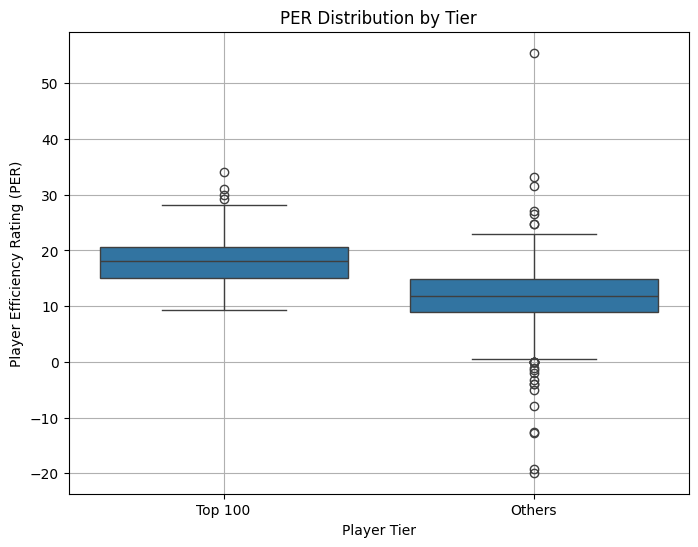

In [ ]:
# Side-by-side boxplot for PER
plt.figure(figsize=(8, 6))
sns.boxplot(x='Tier', y='PER', data=nba_df)
plt.title('PER Distribution by Tier')
plt.xlabel('Player Tier')
plt.ylabel('Player Efficiency Rating (PER)')
plt.grid(True)
plt.show()

#4. Statistical Hypothesis Test

The statistical hypothesis can be broken down between the Null and Alternative Hypothesis.

Null Hypothesis: Players placement in the top 100 has no impact on the players PER

Alternative Hypothesis: Players placed in the top 100 have higher PER than the general population of players

We are looking to reject the null hypothesis. We can test this through two main ways, observed difference and p-value test.

To test with observed difference we will want to create a histogram of sample populations differences. The sample populations will be created through grabbing data from the original data set without replacement to create an empirical distribution of mean PER differences and if the observed difference falls past the distribution reject the null hypothesis. With the p-value test I'll compare the p-value against a standard significance level of 0.05 or 5% and if it is lower reject the null.

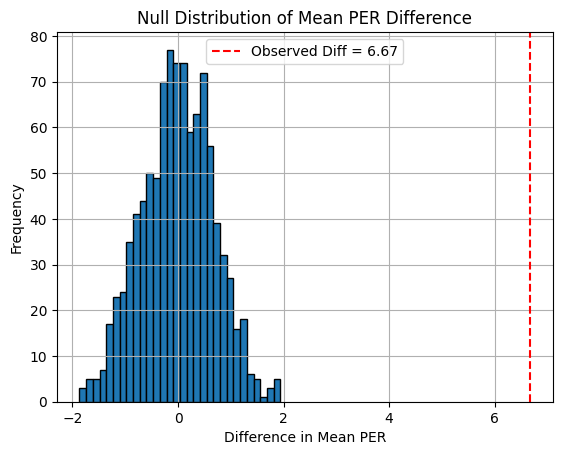

P-value: 0.0000


In [ ]:
# Observed difference in means
mean_top = top_df['PER'].mean()
mean_bottom = bottom_df['PER'].mean()
observed_diff = mean_top - mean_bottom

# Combine PER values and shuffle
combined = nba_df['PER'].values
labels = nba_df['Tier'].values

# Simulate null distribution
np.random.seed(42)
simulated_diffs = []
for _ in range(1000):
    shuffled = np.random.permutation(combined)
    sim_top = shuffled[:len(top_df)]
    sim_bottom = shuffled[len(top_df):]
    simulated_diffs.append(sim_top.mean() - sim_bottom.mean())

# Plot the null distribution
plt.hist(simulated_diffs, bins=30, edgecolor='k')
plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed Diff = {observed_diff:.2f}')
plt.title('Null Distribution of Mean PER Difference')
plt.xlabel('Difference in Mean PER')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Calculate p-value
p_value = np.mean([diff >= observed_diff for diff in simulated_diffs])
print(f"P-value: {p_value:.4f}")


With this data we can see the observed difference is way past the empirical distribution that has been found. This also demonstrates that the p-value is 0.00 or 0% which is below the 0.05 threshold. With that said, both tests reject the null hypothesis giving more credibility to the alternative hypothesis.

#5. Prediction Method with Linear Regression

For the second question:

2. What is the nature of the relationship between Player Efficiency Rating (PER) and Box Plus Minus (BPM) in all the NBA players?

We can use a regression line through a scatter plot comparing the two values. Since we are determining if PER has a relationship with BPM we will plot PER on the x-axis and BPM on the y-axis. We can use the average of the BPM/PER to find the slope of the regression line which indicates the direction and strength of the relationship.

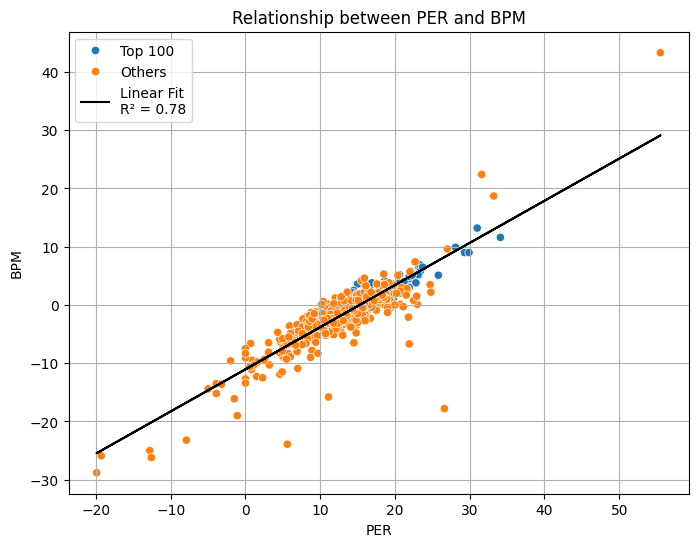

In [ ]:
# Load and prepare data
top_df = pd.read_excel("toptier.xlsx"); top_df["Tier"] = "Top 100"
bottom_df = pd.read_csv("bottom tier.csv"); bottom_df["Tier"] = "Others"
nba_df = pd.concat([top_df, bottom_df], ignore_index=True).dropna(subset=['PER', 'BPM']).copy()

# Linear Regression
x, y = nba_df['PER'], nba_df['BPM']
n, sx, sy, sxy, sxx = len(x), np.sum(x), np.sum(y), np.sum(x * y), np.sum(x**2)
m = (n * sxy - sx * sy) / (n * sxx - sx**2)
b = np.mean(y) - m * np.mean(x)
r2 = ((np.sum((m * x + b - np.mean(y))**2)) / (np.sum((y - np.mean(y))**2)))

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PER', y='BPM', data=nba_df, hue='Tier')
plt.plot(x, m * x + b, color='black', label=f'Linear Fit\nR² = {r2:.2f}')
plt.title('Relationship between PER and BPM'); plt.xlabel('PER'); plt.ylabel('BPM'); plt.legend(); plt.grid(True); plt.show()

In [ ]:
# Drop rows with missing values
nba_clean = nba_df.dropna(subset=['PER', 'BPM']).copy()

# Extract data
X = nba_clean['PER']
y = nba_clean['BPM']

n = len(X)
slope = (n * np.sum(X * y) - np.sum(X) * np.sum(y)) / (n * np.sum(X**2) - (np.sum(X))**2)
intercept = np.mean(y) - slope * np.mean(X)
r_squared = 1 - (np.sum((y - (slope * X + intercept))**2) / np.sum((y - np.mean(y))**2))

# Results
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_squared}")

Slope: 0.7232643654239316
Intercept: -11.043383997655992
R-squared: 0.782522550601173


As shown, the relationship between the two and the regression line found is positive, at a slope of 0.723, proving that on average the higher the PER the higher the BPM. The regression line is also a strong fit as the R^2 value is very high at 0.78 showing that it is a fairly accurate predictor.

#6. Conclusions

With all the information found, we can conclude a main point for each of the previous questions. The first point is we can reject the idea that being in the top 100 has no impact on the players PER and we can favor the notion that being in the top 100 means the player may have a higher PER than the average. The second point that we can make is that there is a positive relationship between a player's PER and BPM where as the PER goes higher the BPM gets higher.